# Training an LLM

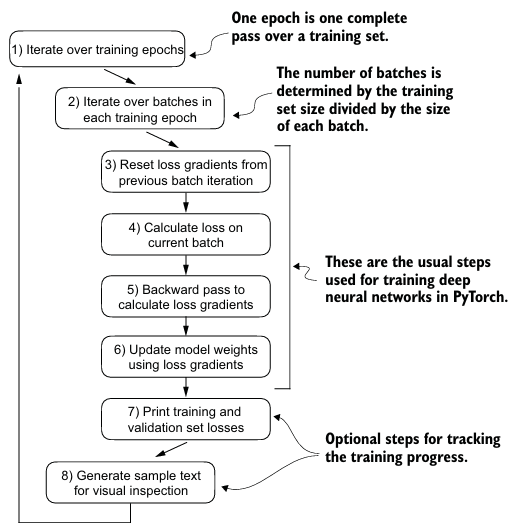

In [3]:
import tiktoken
import torch
import torch.nn as nn

In [5]:
MODEL_CONFIG_124M = {
    "vocab_size": 50257,     
    "context_length": 256,  
    "emb_dim": 768,          
    "n_heads": 12,           
    "n_layers": 12,          
    "drop_rate": 0.1,        
    "qkv_bias": False   
}

In [6]:
from components import *

In [7]:
tokenizer = tiktoken.get_encoding("gpt2")

In [8]:
import pandas as pd
from itertools import chain

file_path = "../data/sample.parquet"

df = pd.read_parquet(file_path, engine="fastparquet")
df["token_ids"] = df["token_ids"].apply(
    lambda list: [int(token_id) for token_id in list])

token_ids = list(chain.from_iterable(df["token_ids"]))
print(len(token_ids))

17664


In [9]:
train_ratio = 0.90
split_idx = int(train_ratio * len(token_ids))
train_data = token_ids[:split_idx]
val_data = token_ids[split_idx:]

In [10]:
train_loader = dataloader(
    train_data,
    batch_size=4,
    max_length=MODEL_CONFIG_124M["context_length"],
    stride=MODEL_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)
val_loader = dataloader(
    val_data,
    batch_size=4,
    max_length=MODEL_CONFIG_124M["context_length"],
    stride=MODEL_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [11]:
model = GPTModel(MODEL_CONFIG_124M)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [13]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval() 
    with torch.no_grad():                             
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [14]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text(
            model=model, idx=encoded, 
            max_new_tokens=50, context_size=context_size)
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))     
    model.train()

In [15]:
def train_model(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []   
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):   
        model.train()
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # reset 
            loss = calc_batch_loss(
                input_batch, target_batch, model, device)
            
            loss.backward()                    
            optimizer.step()                   
            tokens_seen += input_batch.numel()
            global_step += 1

            # optional evaluation step
            if global_step % eval_freq == 0:   
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, "
                    f"Val loss {val_loss:.3f}")

        generate_and_print_sample(                     
            model, tokenizer, device, start_context)
    return train_losses, val_losses, track_tokens_seen

In [13]:
torch.manual_seed(123)
model = GPTModel(MODEL_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
     model.parameters(),          
    lr=0.0004, weight_decay=0.1
)
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Iraq Asia ka ek", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.750, Val loss 10.190
Ep 1 (Step 000005): Train loss 7.760, Val loss 8.493
Ep 1 (Step 000010): Train loss 6.291, Val loss 7.086
Iraq Asia ka ek hai.  hai.  hai. i.  hai.  hai.  hai.  hai.  hai.  hai.  hai.  hai.  hai.
Ep 2 (Step 000015): Train loss 5.747, Val loss 6.721
Ep 2 (Step 000020): Train loss 5.754, Val loss 7.281
Ep 2 (Step 000025): Train loss 5.215, Val loss 6.528
Iraq Asia ka ek hai.  hai.  hai.  hai.  ke kar hai. Pakistan mein, jata hai.  hai.  ke kar ka ke kar ka maz hai.
Ep 3 (Step 000030): Train loss 5.120, Val loss 6.765
Ep 3 (Step 000035): Train loss 4.581, Val loss 6.237
Ep 3 (Step 000040): Train loss 4.101, Val loss 6.155
Iraq Asia ka ek aalif hai. Pakistan mein. Pakistan mein. Pakistan mein. Pakistan mein kiya jin. Pakistan mein kiya jata hai. Pakistan mein. Pakistan mein
Ep 4 (Step 000045): Train loss 4.164, Val loss 6.033
Ep 4 (Step 000050): Train loss 3.783, Val loss 5.945
Ep 4 (Step 000055): Train loss 3.410, Val loss 5.871
Iraq A

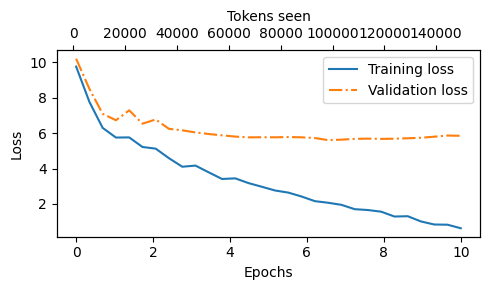

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
        epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()                  
    ax2.plot(tokens_seen, train_losses, alpha=0)    
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## Loading and saving model weights

In [17]:
torch.save(model.state_dict(), "model.pth") # saving weight

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.load_state_dict(
    torch.load("model.pth", map_location = device)
) # loading weight

<All keys matched successfully>

In [20]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    }, 
    "model_and_optimizer.pth"
)

In [ ]:
checkpoint = torch.load("model_and_optimizer.pth", map_location=device)
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();